In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

# Import packages that will be used
import c2qa
from custom_gates import state_transfer
import features
import numpy as np
import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, visualization, AncillaRegister,QuantumRegister
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from qiskit.quantum_info import state_fidelity, Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info.operators.predicates import is_unitary_matrix
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library.standard_gates import HGate
from math import pi, ceil
import scipy
from c2qa.operators import CVOperators
from c2qa.qumoderegister import QumodeRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from c2qa.parameterized_unitary_gate import ParameterizedUnitaryGate
from qutip import *

In [2]:
cutoff = 2**6
osc_init = coherent(cutoff,-2) + coherent(cutoff,2)

In [3]:
Ust = state_transfer.dv2cv_st_non_abelian(0.29,4,cutoff)
Ust1 = Ust.dag()

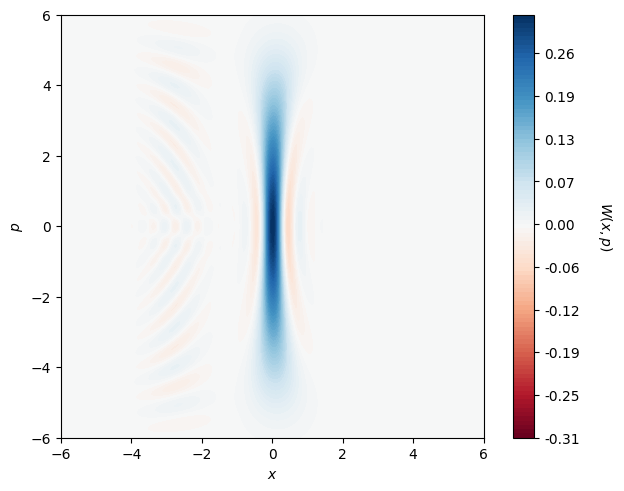

In [4]:
def apply_basis_transformation(circuit, qbr1):
    num_qubits = len(qbr1)
    for i in range(num_qubits):
        circuit.h(qbr1[i])
        if i == num_qubits - 1:  # MSB
            circuit.x(qbr1[i])
            circuit.z(qbr1[i])
        elif i == 0:  # LSB
            circuit.z(qbr1[i])
        else:  # Middle qubits
            circuit.x(qbr1[i])

# Initialize the circuit
qbm = 4
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6,name='qmode')
qbr1 = QuantumRegister(4)
cr1 = ClassicalRegister(4)
circuit = c2qa.CVCircuit(qmr, qbr1, cr1)

# Initialize the CV qumode
circuit.cv_initialize(osc_init.full(), qmr[0])
circuit.barrier(label='')

# Add the CV-to-DV transfer gate
gate1 = UnitaryGate(Ust1.full(), label='cST')
circuit.append(gate1, qmr[:] + qbr1[:])

circuit.barrier()

# Apply basis transformation
apply_basis_transformation(circuit, qbr1)

circuit.barrier()

# Simulate and measure
st0 = Statevector.from_instruction(circuit)
for i in range(len(qbr1)):
    circuit.measure(qbr1[i], cr1[-(i + 1)])

state1, result, _ = c2qa.util.simulate(circuit, shots=1024)
c2qa.wigner.plot_wigner(circuit, state1)

In [5]:
circuit_metrics = features.collect_cvcircuit_metrics(circuit,cutoff)

In [6]:
print(circuit_metrics)

{'Qubits': 4, 'Qumodes': 1, 'Qubit Gates': 9, 'Qumode Gates': 0, 'Hybrid Gates': 1, 'Total Gates': 10}


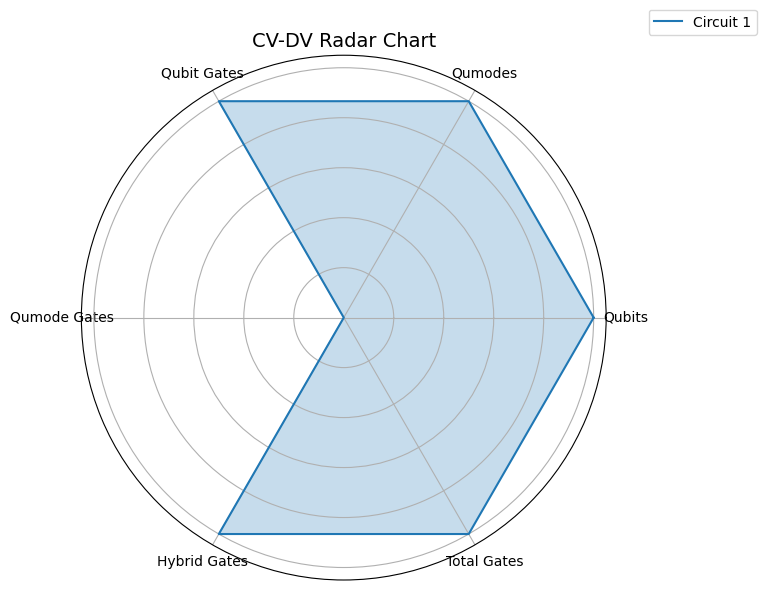

In [7]:
features.plot_radar_metrics([circuit_metrics])